In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.model_selection import train_test_split # Added this
from sklearn.metrics import accuracy_score

# Feature 1: CGPA (out of 10)
# Feature 2: Resume Score (out of 10)
# Target: Placed (1 = Yes, 0 = No)

data = {
    'cgpa': [4.5, 5.0, 5.5, 6.0, 6.2, 6.5, 7.0, 7.2, 7.5, 7.8, 
             8.0, 8.2, 8.5, 8.8, 9.0, 9.2, 9.5, 9.6, 9.8, 9.9],
    'resume_score': [3.1, 4.0, 3.8, 4.5, 5.1, 4.8, 5.5, 6.0, 6.2, 6.8, 
                     7.1, 7.5, 7.8, 8.2, 8.5, 9.0, 9.1, 9.4, 9.5, 9.8],
    'placed': [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 
               1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)

# Splitting into X (Features) and y (Target)
X = df[['cgpa', 'resume_score']].values
y = df['placed'].values

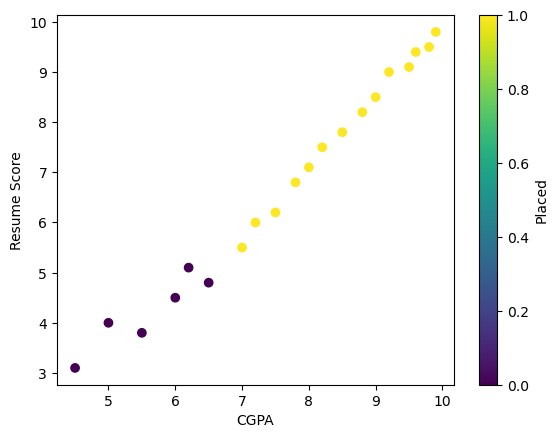

In [2]:
# scatter plot
import matplotlib.pyplot as plt

plt.scatter(df['cgpa'], df['resume_score'], c=df['placed'], cmap='viridis')
plt.xlabel('CGPA')
plt.ylabel('Resume Score')
plt.colorbar(label='Placed')
plt.show()

In [4]:
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
class ProfessionalPerceptron:
    def __init__(self, learning_rate=0.1, epochs=1000): # Increased epochs for random picking
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None

    def fit_random(self, X, y):
        X = np.insert(X, 0, 1, axis=1)
        self.weights = np.zeros(X.shape[1])

        for _ in range(self.epochs):
            # Pick a random student index
            i = random.randint(0, len(X) - 1)

            # Calculate score for THAT random student
            score = np.dot(self.weights, X[i])
            
            y_pred = 1 if score > 0 else 0

            # Update weights based on that one student
            error = y[i] - y_pred
            self.weights = self.weights + (self.lr * error * X[i])

    def predict(self, X):
        X = np.insert(X, 0, 1, axis=1)
        score = np.dot(X, self.weights)
        return np.array([1 if s > 0 else 0 for s in score])

In [14]:
# creating own model
model = ProfessionalPerceptron(learning_rate=0.55, epochs=1000)
model.fit_random(X_train, y_train)

from sklearn.metrics import accuracy_score
print(f"Final Weights (Bias, CGPA, Resume): {model.weights}")

Final Weights (Bias, CGPA, Resume): [-16.5  -17.05  23.87]


In [15]:
y_pred_test = model.predict(X_test) # Added this to calculate acc
acc = accuracy_score(y_test, y_pred_test)

from sklearn.metrics import accuracy_score
print("Accuracy:", acc)
print("Accuracy %:", acc * 100)

Accuracy: 1.0
Accuracy %: 100.0


In [16]:
from sklearn.metrics import accuracy_score

new_student = np.array([[1.56, 10.678]])
prediction = model.predict(new_student)
print("Prediction:", prediction)

Prediction: [1]


In [17]:
# i want to separate the feature with lines
m = - model.weights[1] / model.weights[2]
b = - model.weights[0] / model.weights[2]

print("m:", m)
print("b:", b)

m: 0.7142857142857135
b: 0.6912442396313364


In [20]:
x_input = np.linspace(-3, 3, 100)
y_input = m * x_input + b

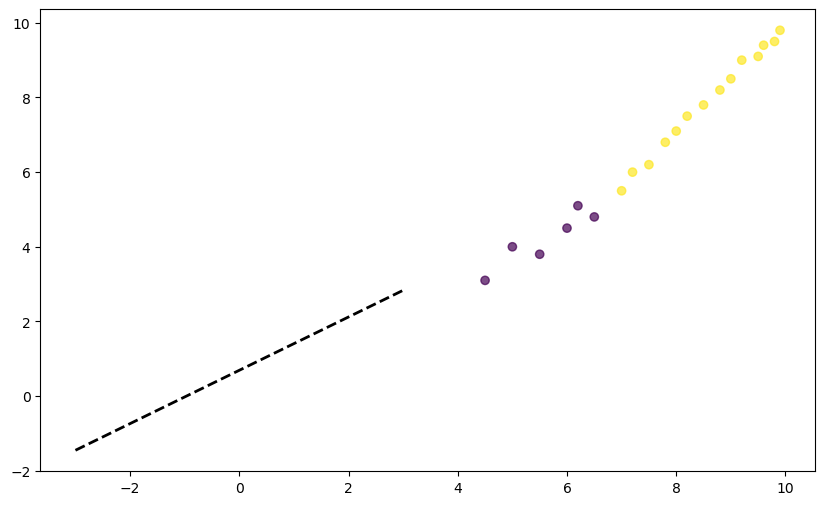

In [22]:
plt.figure(figsize=(10, 6))

plt.scatter(df['cgpa'], df['resume_score'], c=df['placed'], cmap='viridis', alpha=0.7)
plt.plot(x_input, y_input, color='black', linestyle='--', linewidth=2, label='Separating Line')